# 📱 Screen Time & The Attention Economy — A Data Story

This notebook walks through a survey dataset of college students to explore **how our phones compete for our attention** — and what price we pay for it.

We'll answer big questions like:
- How much time do students *really* spend on screens?
- Are notifications *causing* us to pick up phones, or is it just habit?
- Is screen time distributed fairly, or do some students bear a disproportionate burden?
- Does where you live (hostel vs. commuter) affect your digital life?
- Does more screen time *actually* hurt your grades — or is something else going on?

---

## 🔧 Setup & Data Loading

We start by importing our tools and loading the survey data.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# Style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 120

# Load Data
# df = pd.read_csv('simulated_attention.csv')
df = pd.read_csv('.csv') # ###

df.head()

,Age,Gender at Birth,Current Semester,Living Situation,Current CGPA,Average Nightly Sleep (hours),Primary Device Operating System,Total Screen Time Yesterday,Total Device Pickups / Times Unlocked,Total Notifications Received
0,21,Female,2nd,Day Scholar (Commuter),8.60,7.7,iOS (iPhone),30,58,110
1,22,Male,4th,Day Scholar (Commuter),8.05,7.3,iOS (iPhone),221,136,123
2,20,Male,6th,Day Scholar (Commuter),7.70,7.4,iOS (iPhone),102,74,101
3,22,Male,5th,Day Scholar (Commuter),6.95,7.5,iOS (iPhone),102,115,124
4,22,Male,2nd,Day Scholar (Commuter),8.43,7.2,iOS (iPhone),169,51,109


In [2]:
df.describe()

,Age,Current CGPA,Average Nightly Sleep (hours),Total Screen Time Yesterday,Total Device Pickups / Times Unlocked,Total Notifications Received
count,40.000000,40.000000,40.000000,40.00000,40.000000,40.000000
mean,20.850000,8.066000,7.337500,164.17500,94.700000,115.700000
std,1.511494,0.687816,0.709528,96.28507,37.461228,13.042731
min,18.000000,6.940000,5.700000,30.00000,37.000000,94.000000
25%,20.000000,7.690000,7.000000,102.00000,66.500000,106.000000
50%,21.000000,8.045000,7.300000,132.00000,89.000000,113.500000
75%,22.000000,8.430000,7.800000,203.75000,125.500000,123.250000
max,23.000000,9.460000,8.700000,473.00000,176.000000,152.000000


---

## 1. 📊 The Attention Baseline — How much time do we *actually* spend?

### What this does
We simply calculate the **average screen time** across all students in the survey.

### In plain English
Think of it like taking everyone's screen time report and finding the middle ground. This single number gives us a "normal" benchmark — if you're way above it, you might be spending more time on your phone than most of your peers.

📱 Average Screen Time: 164.2 minutes (2.7 hours)
📱 Median  Screen Time: 132.0 minutes (2.2 hours)


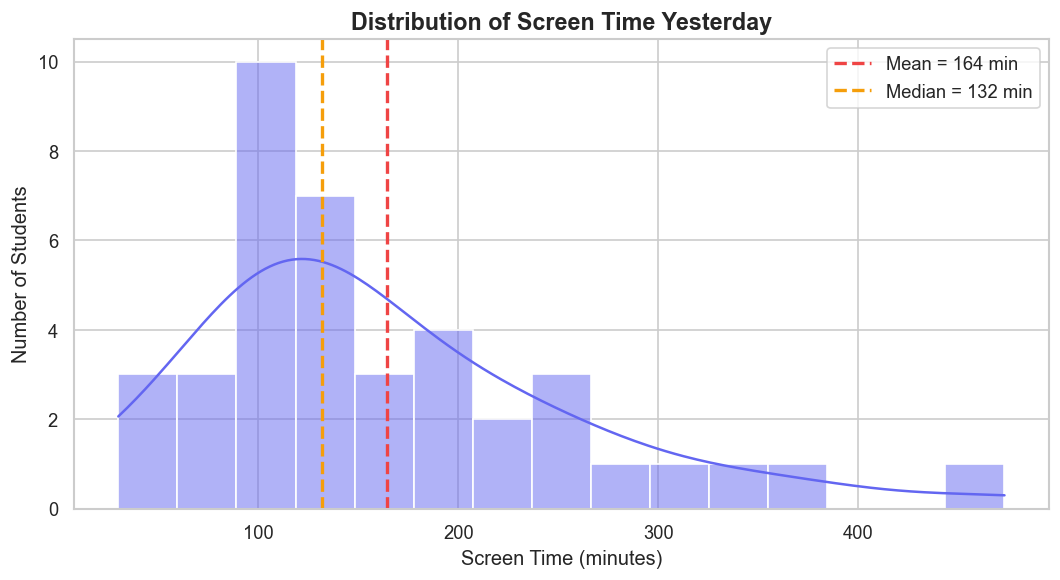

In [3]:
avg = df['Total Screen Time Yesterday'].mean()
median = df['Total Screen Time Yesterday'].median()

print(f"📱 Average Screen Time: {avg:.1f} minutes ({avg/60:.1f} hours)")
print(f"📱 Median  Screen Time: {median:.1f} minutes ({median/60:.1f} hours)")

plt.figure(figsize=(9, 5))
sns.histplot(df['Total Screen Time Yesterday'], bins=15, kde=True, color='#6366f1', edgecolor='white')
plt.axvline(avg, color='#ef4444', linestyle='--', linewidth=2, label=f'Mean = {avg:.0f} min')
plt.axvline(median, color='#f59e0b', linestyle='--', linewidth=2, label=f'Median = {median:.0f} min')
plt.title('Distribution of Screen Time Yesterday', fontsize=14, fontweight='bold')
plt.xlabel('Screen Time (minutes)')
plt.ylabel('Number of Students')
plt.legend()
plt.tight_layout()
plt.show()

> **Key Insight:** If the mean is *higher* than the median, it means a few heavy users are pulling the average up — there's a "long tail" of high-screen-time students.

---

## 2. 🔔 Push vs. Pull — Are *notifications* driving you, or is it *habit*?

### What this does
We plot **notifications received** (the "Push" from apps) against **device pickups** (the "Pull" — you reaching for your phone). A red dashed line shows a perfect 1:1 ratio.

### In plain English
Imagine two scenarios:
- **Push:** Every time you pick up your phone, it's because an app *pinged* you. Your pickups and notifications would match 1:1.
- **Pull:** You pick up your phone out of *boredom or habit*, even when nothing new has happened. Pickups would be **higher** than notifications.

If most dots sit **above** the red line → students pick up phones more than they're notified → it's mostly **habit**.
If most dots sit **below** the red line → notifications are piling up but students resist → they have **self-control**.
If dots cluster **on** the line → every notification leads to a pickup → apps have **perfect control** over your attention.

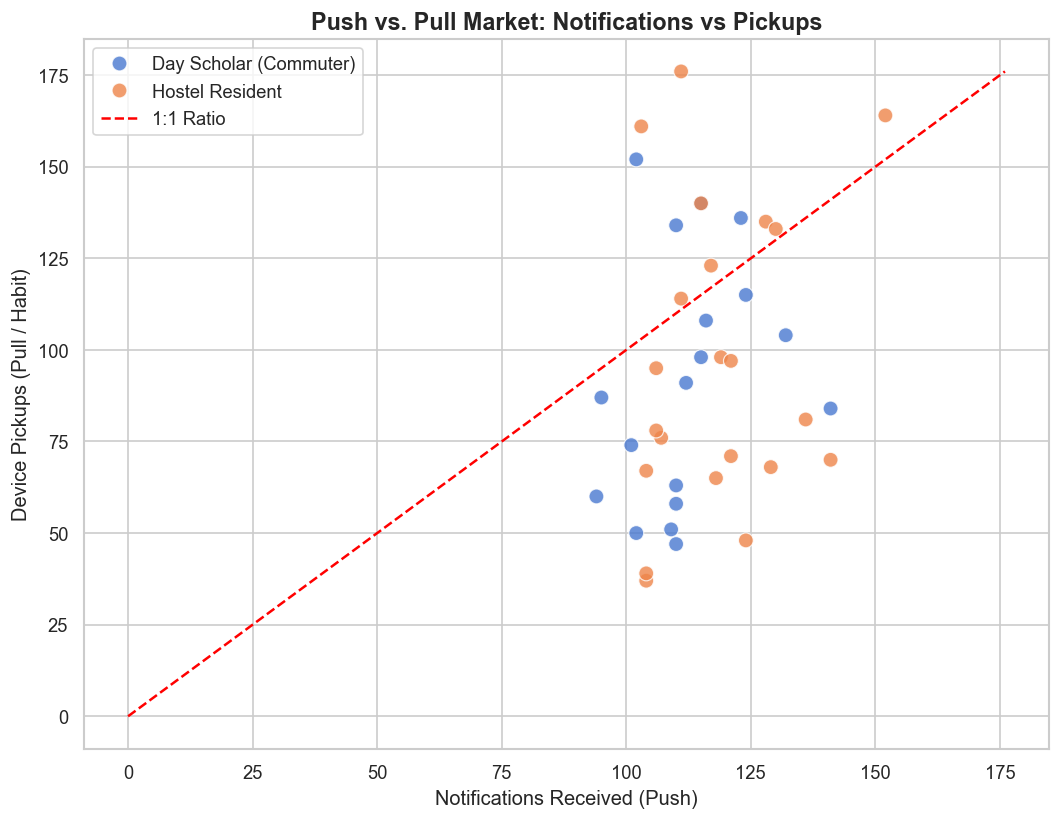

In [4]:
plt.figure(figsize=(9, 7))
sns.scatterplot(
    x='Total Notifications Received',
    y='Total Device Pickups / Times Unlocked',
    data=df,
    hue='Living Situation',
    s=80,
    alpha=0.8,
    edgecolor='white'
)
max_val = max(
    df['Total Notifications Received'].max(),
    df['Total Device Pickups / Times Unlocked'].max()
)
plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', linewidth=1.5, label="1:1 Ratio")
plt.title('Push vs. Pull Market: Notifications vs Pickups', fontsize=14, fontweight='bold')
plt.xlabel('Notifications Received (Push)', fontsize=12)
plt.ylabel('Device Pickups (Pull / Habit)', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

> **Why it matters:** If you find that habit-driven pickups dominate, then simply turning off notifications won't solve the problem — you'd need to address the *underlying habit loop* itself.

---

## 3. 📉 The Lorenz Curve — Is attention time distributed *fairly*?

### What this does
A **Lorenz Curve** is borrowed from economics (where it measures income inequality). Here, we use it to measure **screen-time inequality** among students.

### In plain English
Imagine lining up all 40 students from the *least* screen time to the *most*.
- The red dashed line = **perfect equality** — everyone uses their phone the exact same amount.
- The purple curve = **reality**.

The further the purple curve bows away from the red line, the more **unequal** the distribution is. A huge bow means a small group of students account for a *massive* share of total screen time — they're the "attention whales."

Think of it like wealth: if the bottom 50% of students only account for 20% of total screen time, the top 50% are consuming a disproportionate 80%.

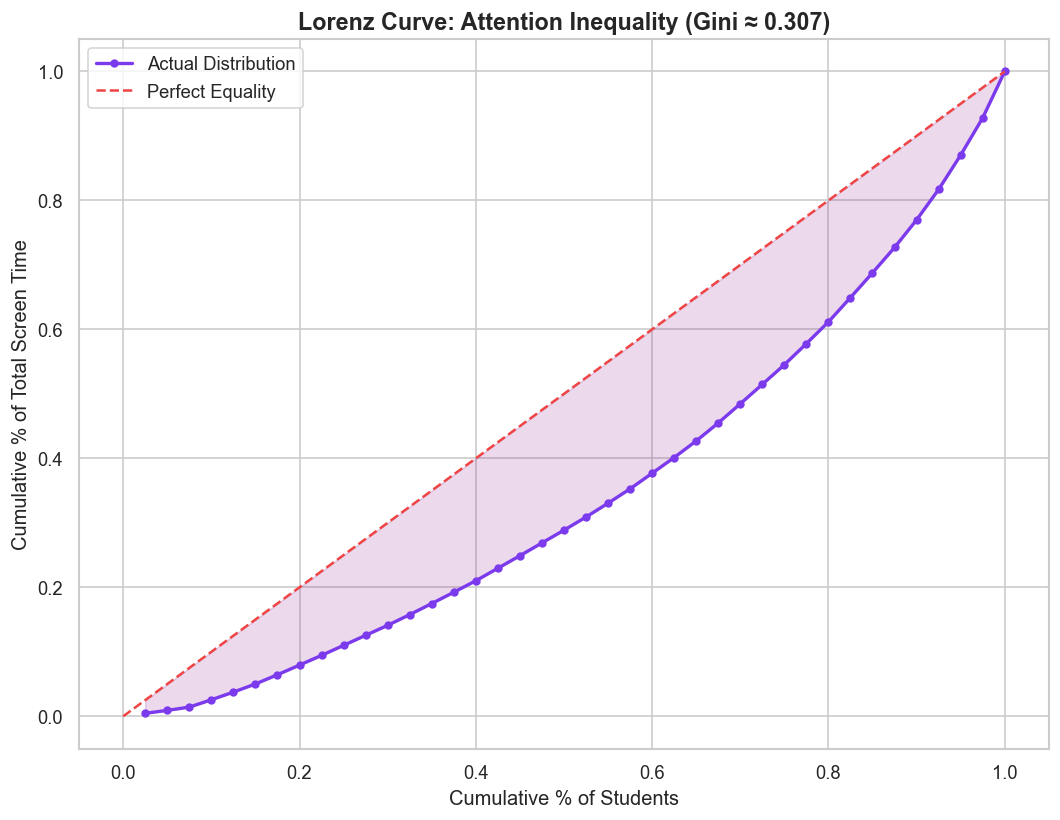

Gini Coefficient ≈ 0.307
  0.0 = perfect equality (everyone same screen time)
  1.0 = perfect inequality (one person has ALL the screen time)


In [5]:
sorted_time = np.sort(df['Total Screen Time Yesterday'])
cum_time = np.cumsum(sorted_time) / sorted_time.sum()
cum_people = np.arange(1, len(df) + 1) / len(df)

# Calculate a simple Gini-like coefficient
area_under_lorenz = np.trapz(cum_time, cum_people)
gini = 1 - 2 * area_under_lorenz

plt.figure(figsize=(9, 7))
plt.fill_between(cum_people, cum_time, cum_people, alpha=0.15, color='purple')
plt.plot(cum_people, cum_time, marker='o', markersize=4, color='#7c3aed', linewidth=2, label='Actual Distribution')
plt.plot([0,1], [0,1], color='#ef4444', linestyle='--', linewidth=1.5, label='Perfect Equality')
plt.title(f'Lorenz Curve: Attention Inequality (Gini ≈ {gini:.3f})', fontsize=14, fontweight='bold')
plt.xlabel('Cumulative % of Students', fontsize=12)
plt.ylabel('Cumulative % of Total Screen Time', fontsize=12)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

print(f"Gini Coefficient ≈ {gini:.3f}")
print(f"  0.0 = perfect equality (everyone same screen time)")
print(f"  1.0 = perfect inequality (one person has ALL the screen time)")

> **Key Insight:** A moderate Gini (~0.2–0.3) is normal. A high value (>0.4) would suggest that screen-time "addiction" is concentrated in a small group who might need targeted interventions rather than blanket policies.

---

## 4. 🏠 The Commuter Tax — Does where you live change your digital life?

### What this does
We compare screen time between students who **live in hostels** vs. those who **commute** (day scholars) using a box plot.

### In plain English
A **box plot** is like a summary of each group:
- The box shows where the middle 50% of students fall.
- The line in the middle of the box is the median.
- The "whiskers" extend to show the full range.
- Dots outside the whiskers are outliers.

**"Commuter Tax"** is the idea that commuting students might use their phones *differently* — maybe more during transit (maps, music, social media to kill time), or maybe *less* because they're physically busy. This chart reveals which story the data tells.

C:\Users\adity\AppData\Local\Temp\ipykernel_35832\3609645093.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


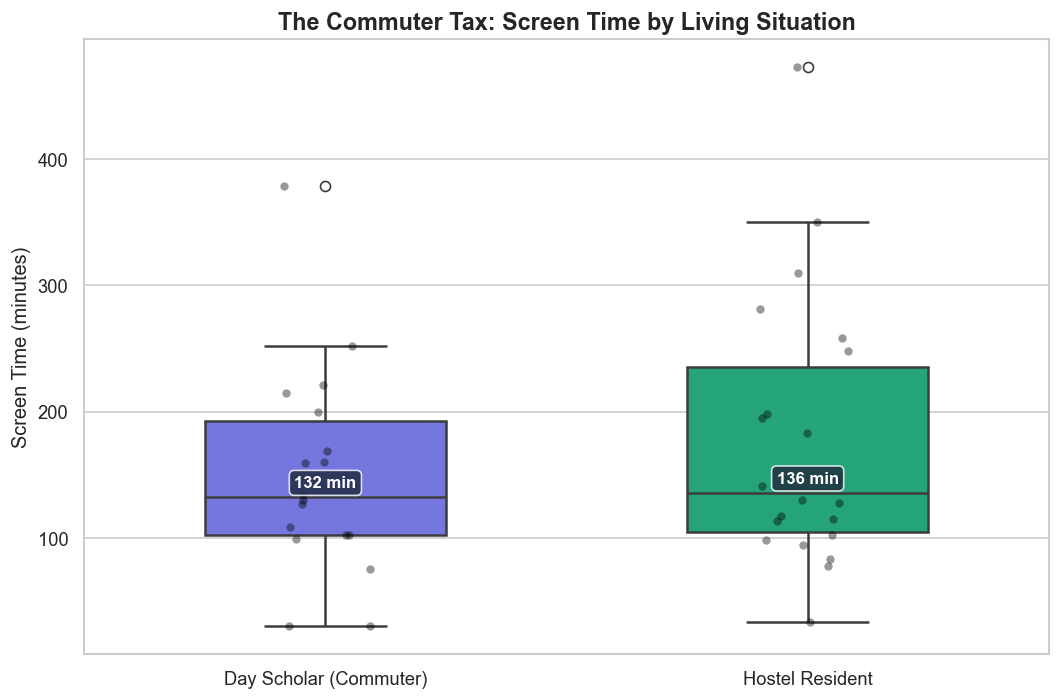


Group Statistics:
                        count   mean    std   min    25%    50%    75%    max
Living Situation                                                             
Day Scholar (Commuter)   18.0  149.6   83.9  30.0  102.0  132.0  192.2  379.0
Hostel Resident          22.0  176.1  105.8  33.0  104.8  135.5  235.5  473.0


In [6]:
plt.figure(figsize=(9, 6))

ax = sns.boxplot(
    x='Living Situation',
    y='Total Screen Time Yesterday',
    data=df,
    palette=['#6366f1', '#10b981'],
    width=0.5,
    linewidth=1.5
)
sns.stripplot(
    x='Living Situation',
    y='Total Screen Time Yesterday',
    data=df,
    color='black',
    alpha=0.4,
    size=5,
    jitter=True
)

# Annotate medians
medians = df.groupby('Living Situation')['Total Screen Time Yesterday'].median()
for i, (cat, med) in enumerate(medians.items()):
    ax.text(i, med + 8, f'{med:.0f} min', ha='center', fontsize=10, fontweight='bold', color='white',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#1e293b', alpha=0.8))

plt.title('The Commuter Tax: Screen Time by Living Situation', fontsize=14, fontweight='bold')
plt.ylabel('Screen Time (minutes)', fontsize=12)
plt.xlabel('')
plt.tight_layout()
plt.show()

print("\nGroup Statistics:")
print(df.groupby('Living Situation')['Total Screen Time Yesterday'].describe().round(1))

> **Why it matters:** If commuters have significantly different screen time, it tells us that **context** (your environment, routine, commute time) shapes digital behavior — not just willpower.

---

## 5. 📉 OLS Regression: The Opportunity Cost — Does screen time hurt grades?

### What this does
We run an **Ordinary Least Squares (OLS) regression** — a statistical model that draws the "best fit" line between screen time and CGPA.

### In plain English
Imagine plotting every student as a dot on a chart (screen time on X-axis, CGPA on Y-axis) and then drawing the *one* straight line that best passes through all those dots.

- **Coefficient** (coef): How much CGPA changes for each extra minute of screen time. A *negative* number means more screen time = lower CGPA.
- **P-value** (P>|t|): How confident are we that this isn't just random noise?
  - **P < 0.05** → "We're over 95% confident this effect is real."
  - **P > 0.05** → "We're not confident. This could just be chance."

⚠️ **Remember: correlation ≠ causation.** Even if we find a link, it doesn't mean *screen time caused* lower grades. There could be a hidden variable pulling the strings behind the scenes...

In [7]:
print("=" * 60)
print("MODEL 1: Screen Time → CGPA (Simple Regression)")
print("=" * 60)

X1 = sm.add_constant(df['Total Screen Time Yesterday'])
y = df['Current CGPA']
model1 = sm.OLS(y, X1).fit()

print(model1.summary().tables[1])
print(f"\nR² = {model1.rsquared:.3f}  →  Screen time explains {model1.rsquared*100:.1f}% of CGPA variation")

MODEL 1: Screen Time → CGPA (Simple Regression)
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const                           8.7478      0.179     48.902      0.000       8.386       9.110
Total Screen Time Yesterday    -0.0042      0.001     -4.404      0.000      -0.006      -0.002

R² = 0.338  →  Screen time explains 33.8% of CGPA variation


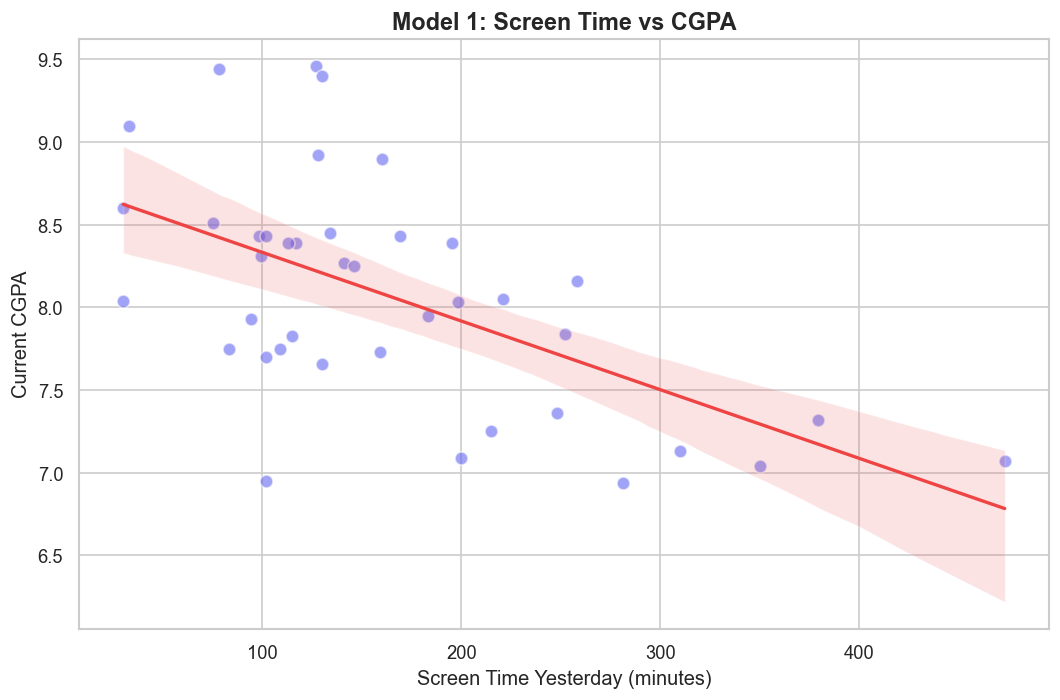

In [8]:
# Visualize Model 1
plt.figure(figsize=(9, 6))
sns.regplot(
    x='Total Screen Time Yesterday',
    y='Current CGPA',
    data=df,
    scatter_kws={'alpha': 0.6, 's': 60, 'edgecolor': 'white'},
    line_kws={'color': '#ef4444', 'linewidth': 2},
    color='#6366f1'
)
plt.title('Model 1: Screen Time vs CGPA', fontsize=14, fontweight='bold')
plt.xlabel('Screen Time Yesterday (minutes)', fontsize=12)
plt.ylabel('Current CGPA', fontsize=12)
plt.tight_layout()
plt.show()

> **Interpretation:** If the p-value for screen time is < 0.05, we'd conclude: "Yes, more screen time is statistically associated with lower CGPA." But hold on — let's see what happens when we account for *sleep*...

---

## 6. 🧠 The Plot Twist: Omitted Variable Bias — Sleep steals the show!

### What this does
We add **sleep hours** as a second variable into the regression alongside screen time. This is called a **multiple regression**.

### In plain English
**Omitted Variable Bias** is one of the most important concepts in data analysis. Here's the story:

1. In Model 1, we saw that screen time seemed to *hurt* grades.
2. But what if the *real* story is: **students who sleep less have lower grades**, and those same students *also* happen to use their phones more (because they're up late scrolling)?
3. In that case, screen time was just a **messenger** — it was *correlated* with the real culprit (lack of sleep), but it wasn't the *cause*.

This is like blaming the rooster for the sunrise. The rooster crows before sunrise (correlated), but it doesn't *cause* the sun to rise.

### What to look for
- If screen time's p-value was < 0.05 in Model 1 but **jumps above 0.05** in Model 2 → Screen time was a *false lead*. Sleep was the real driver all along.
- If sleep's p-value is < 0.05 → Sleep is the statistically significant predictor of CGPA.

In [9]:
print("=" * 60)
print("MODEL 2: Screen Time + Sleep → CGPA (Multiple Regression)")
print("=" * 60)

X2 = sm.add_constant(df[['Total Screen Time Yesterday', 'Average Nightly Sleep (hours)']])
model2 = sm.OLS(y, X2).fit()

print(model2.summary().tables[1])
print(f"\nR² = {model2.rsquared:.3f}  →  Model now explains {model2.rsquared*100:.1f}% of CGPA variation")

MODEL 2: Screen Time + Sleep → CGPA (Multiple Regression)
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
const                             4.0977      1.140      3.596      0.001       1.789       6.407
Total Screen Time Yesterday      -0.0015      0.001     -1.422      0.163      -0.004       0.001
Average Nightly Sleep (hours)     0.5735      0.139      4.116      0.000       0.291       0.856

R² = 0.546  →  Model now explains 54.6% of CGPA variation


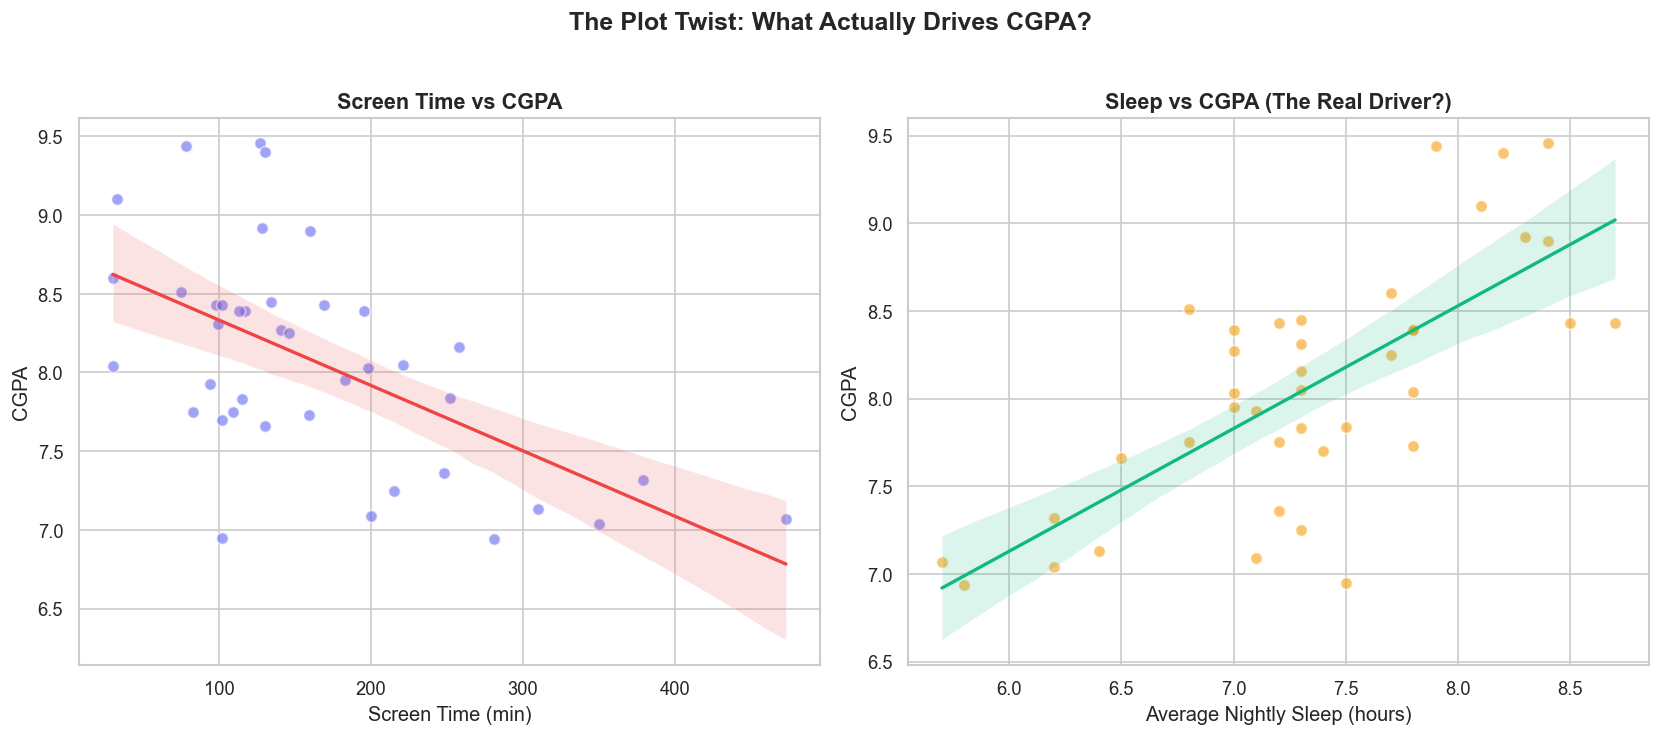

In [10]:
# Side-by-side comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: Screen Time vs CGPA
sns.regplot(
    x='Total Screen Time Yesterday', y='Current CGPA', data=df,
    ax=axes[0],
    scatter_kws={'alpha': 0.6, 's': 50, 'edgecolor': 'white'},
    line_kws={'color': '#ef4444', 'linewidth': 2},
    color='#6366f1'
)
axes[0].set_title('Screen Time vs CGPA', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Screen Time (min)')
axes[0].set_ylabel('CGPA')

# Right: Sleep vs CGPA
sns.regplot(
    x='Average Nightly Sleep (hours)', y='Current CGPA', data=df,
    ax=axes[1],
    scatter_kws={'alpha': 0.6, 's': 50, 'edgecolor': 'white'},
    line_kws={'color': '#10b981', 'linewidth': 2},
    color='#f59e0b'
)
axes[1].set_title('Sleep vs CGPA (The Real Driver?)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Average Nightly Sleep (hours)')
axes[1].set_ylabel('CGPA')

plt.suptitle('The Plot Twist: What Actually Drives CGPA?', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---

## 🎯 Summary & Takeaways

| Analysis | Question | Key Finding |
|---|---|---|
| **Attention Baseline** | How much screen time is "normal"? | Average ≈ X minutes/day |
| **Push vs Pull** | Do apps control us, or do we control ourselves? | Check which side of the 1:1 line dots fall on |
| **Lorenz Curve** | Is screen time spread equally? | Gini coefficient reveals inequality |
| **Commuter Tax** | Does living situation matter? | Box plot comparison shows the gap |
| **OLS Model 1** | Does screen time hurt grades? | P-value tells us if the link is real |
| **OLS Model 2** | ...or was it sleep all along? | Adding sleep may *break* screen time's significance |

### The Big Lesson

> **Never trust a single-variable story.** The world is multivariate. What looks like "phones are ruining grades" might actually be "sleep deprivation is ruining grades, and phones are just along for the ride." Always ask: *"What am I not measuring?"*

---

*Notebook prepared for the ProofGrad Attention Economy lecture series.*